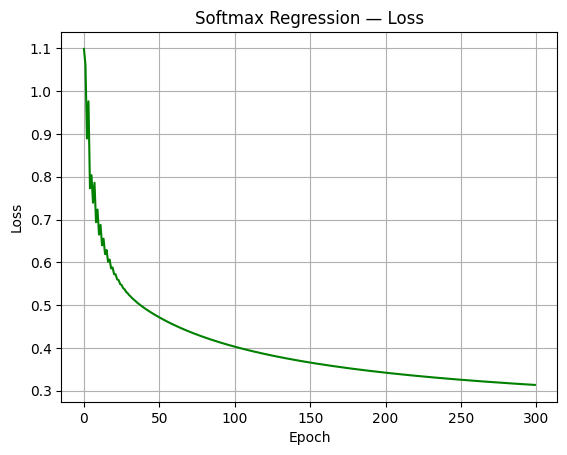

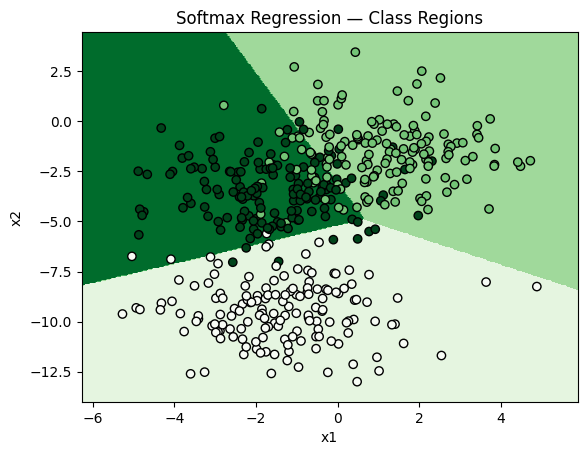

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(2)

X, y = make_blobs(n_samples=450, centers=3, cluster_std=1.5)
K = 3

W = np.zeros((X.shape[1], K))
b = np.zeros(K)
lr = 0.2
epochs = 300
losses = []

def softmax(z):
    z -= z.max(axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / expz.sum(axis=1, keepdims=True)

for _ in range(epochs):
    logits = X.dot(W)+b
    probs = softmax(logits)
    Y = np.zeros_like(probs); Y[np.arange(len(y)), y] = 1
    loss = -np.sum(Y*np.log(probs+1e-12))/len(X)
    losses.append(loss)
    dW = X.T.dot(probs-Y)/len(X)
    db = (probs-Y).mean(axis=0)
    W -= lr*dW
    b -= lr*db

plt.figure()
plt.plot(losses, color="green")
plt.title("Softmax Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
preds = np.argmax(softmax(grid.dot(W)+b), axis=1).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, preds, K, cmap="Greens")
plt.scatter(X[:,0], X[:,1], c=y, cmap="Greens", edgecolor="black")
plt.title("Softmax Regression — Class Regions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

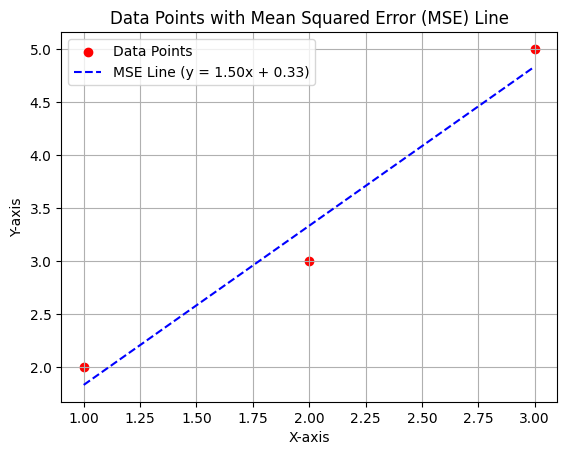

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Extract x and y directly from df so they match
x = [1, 2, 3]
y = [2, 3, 5]

# 1. Calculate the Best-Fit (MSE) Line
# np.polyfit(x, y, 1) calculates a 1st-degree polynomial (y = mx + c)
slope, intercept = np.polyfit(x, y, 1)

# 2. Create y-values for the line using the line equation: y = mx + c
mse_line = [slope * xi + intercept for xi in x]

# 3. Plotting everything
plt.scatter(x, y, color='red', label='Data Points') # Original data points
plt.plot(x, mse_line, color='blue', linestyle='--', label=f'MSE Line (y = {slope:.2f}x + {intercept:.2f})')

# Add labels and legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Data Points with Mean Squared Error (MSE) Line')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

step 1: x = -3.200, f(x) = 10.240
step 2: x = -2.560, f(x) = 6.554
step 3: x = -2.048, f(x) = 4.194
step 4: x = -1.638, f(x) = 2.684
step 5: x = -1.311, f(x) = 1.718
step 6: x = -1.049, f(x) = 1.100
step 7: x = -0.839, f(x) = 0.704
step 8: x = -0.671, f(x) = 0.450
step 9: x = -0.537, f(x) = 0.288
step 10: x = -0.429, f(x) = 0.184
step 11: x = -0.344, f(x) = 0.118
step 12: x = -0.275, f(x) = 0.076
step 13: x = -0.220, f(x) = 0.048
step 14: x = -0.176, f(x) = 0.031
step 15: x = -0.141, f(x) = 0.020
step 16: x = -0.113, f(x) = 0.013
step 17: x = -0.090, f(x) = 0.008
step 18: x = -0.072, f(x) = 0.005
step 19: x = -0.058, f(x) = 0.003
step 20: x = -0.046, f(x) = 0.002
step 21: x = -0.037, f(x) = 0.001
step 22: x = -0.030, f(x) = 0.001
step 23: x = -0.024, f(x) = 0.001
step 24: x = -0.019, f(x) = 0.000


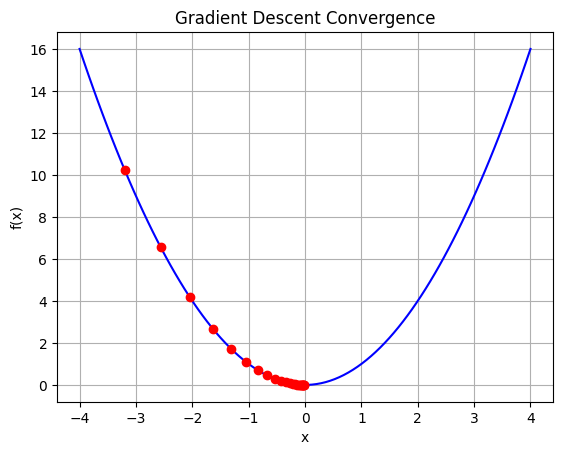

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return x**2
def df(x):
    return 2*x

x0 = -4
alpha = 0.1
epoch = 24
x_history = [x0]
y_history = [f(x0)]

x = x0
x_plot = np.linspace(-4, 4, 100)
y_plot = f(x_plot)
plt.plot(x_plot, y_plot, label=r"$f(x) = x^2$", color='blue')
for epoch in range(epoch):
    gred = df(x)
    x -= alpha*gred

    x_history.append(x)
    y_history.append(f(x))

    print(f"step {epoch+1}: x = {x:.3f}, f(x) = {f(x):.3f}")

    # Plot current position of x
    plt.scatter(x, f(x), color='red', zorder=5)
    # plt.plot(x_history, y_history, color='green', linestyle='--')

# Customize plot appearance

plt.title('Gradient Descent Convergence')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()